# Portfolio Lab Research Walkthrough

This notebook is the third view of the portfolio lab library, besides the [README](../README.md) reporting conclusions and the [methodology notes](../docs/methodology.md) presenting math derivations. 

It shows the way a researcher would actually use with it, not to duplicate `scripts/make_exhibits.py`. Instead it opens up the intermediate objects the exhibits hide, takes a single rebalance apart, and then answers three questions not in the exhibits.

Runs from the committed parquet cache with **zero credentials**. Expect roughly 10-15 minutes end to end, with the backtests in section 4 dominating it.


**What this walkthrough covers.**

1. **The data** — 19 assets, but only about three independent bets. That one fact explains both
   the bond-heavy risk-parity books and ERC's precision floor.
2. **The signals** — three components, only one with a view on the market as a whole. Seeing that
   separated is seeing the point of the differential combine.
3. **A single rebalance** — the engine loop by hand, every intermediate visible, plus a direct
   check of ERC's defining contract.
4. **Three new questions** — does the covariance estimator matter, can a no-trade band replace the
   turnover penalty, which signal is actually earning its place. One `dataclasses.replace` each.
5. **The edge cases** — behaviour on broken inputs, and how many digits of ERC's answer to believe.

To ablate a signal you need the engine to run on a `mu` you supply yourself, and `run_backtest` has no argument for
that — it always computes `mu` internally. So 4c gets there by patching the function at runtime,
which is a testing trick, not a research interface. The capability is all there; what is missing
is a two-line optional argument. 4c spells it out.

In [ ]:
from dataclasses import replace
from unittest.mock import patch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from portlab.attribution import pct_risk_contributions, performance_stats
from portlab.config import Config
from portlab.construction import OPTIMIZER_NAMES, optimize
from portlab.data import load_universe_bars
from portlab.engine import run_backtest
from portlab.estimation import ewma_cov
from portlab.preprocessing import close_panel, daily_returns
from portlab.signals import expected_returns, sigma_daily, st_rev, tsmom, xsmom
from portlab.universe import UNIVERSE, optimized_tickers

pd.set_option("display.width", 120)
CFG = Config()  # The frozen research spec. Every experiment below is a variant of it.
CFG

Config(signals=SignalConfig(tsmom_windows=(63, 126, 252), signal_vol_halflife_days=63, xs_lookback=252, xs_exclude=21, xsmom_scale=2.0, reversal_window=5, clip=2.0), estimation=EstimationConfig(ewma_halflife_days=63, cov_window_days=252, cov_estimator='ewma'), construction=ConstructionConfig(position_cap=0.25, gross_cap=2.0, net_min=-0.5, net_max=1.0, risk_aversion=100.0, turnover_lambda=0.0, vol_target_annual=0.1), engine=EngineConfig(rebalance_freq='B', vol_target=False, no_trade_band=0.0), costs=CostConfig(cost_per_side_bps=5.0))

## 1. Data loading, symbol correlation and volatility

- Load the cached bars
- Align them into a close panel
- Difference them

The panel is the only thing the rest of the library needs.


In [5]:
closes = close_panel(load_universe_bars(tickers=optimized_tickers()))
returns = daily_returns(closes)
print(
    f"{closes.shape[0]} trading days x {closes.shape[1]} assets,"
    f" {closes.index[0].date()} .. {closes.index[-1].date()}"
)
display(closes.tail(3))
display(returns.tail(3))

2644 trading days x 19 assets, 2016-01-04 .. 2026-07-10


,XLK,XLF,XLE,XLV,XLI,XLP,XLY,XLU,XLB,EFA,EEM,SHY,IEF,TLT,LQD,HYG,GLD,DBC,VNQ
date,,,,,,,,,,,,,,,,,,,
2026-07-08,181.40,54.97,55.60,162.30,180.42,84.39,115.30,45.36,50.16,103.36,66.23,81.84,93.51,84.36,107.67,79.66,374.45,27.80,96.80
2026-07-09,185.35,55.54,54.82,162.17,181.11,83.20,116.85,45.13,50.26,103.92,66.78,81.91,93.71,84.49,107.71,79.75,378.18,27.58,97.09
2026-07-10,185.78,55.71,55.08,160.84,181.92,84.12,117.24,45.41,50.89,104.33,66.90,81.88,93.63,84.47,107.46,79.71,377.01,27.52,97.32


,XLK,XLF,XLE,XLV,XLI,XLP,XLY,XLU,XLB,EFA,EEM,SHY,IEF,TLT,LQD,HYG,GLD,DBC,VNQ
date,,,,,,,,,,,,,,,,,,,
2026-07-08,0.012390,-0.019269,0.017570,-0.013014,-0.010747,-0.005539,-0.017804,-0.007440,-0.026209,-0.007680,0.007760,-0.000244,-0.002028,-0.002247,-0.001947,-0.001254,-0.008053,0.016453,-0.016260
2026-07-09,0.021775,0.010369,-0.014029,-0.000801,0.003824,-0.014101,0.013443,-0.005071,0.001994,0.005418,0.008304,0.000855,0.002139,0.001541,0.000372,0.001130,0.009961,-0.007914,0.002996
2026-07-10,0.002320,0.003061,0.004743,-0.008201,0.004472,0.011058,0.003338,0.006204,0.012535,0.003945,0.001797,-0.000366,-0.000854,-0.000237,-0.002321,-0.000502,-0.003094,-0.002175,0.002369


The heterogeneous universe is what the risk-parity optimizers feed on. It also contains the collinear sub-blocks that limit ERC's numerical precision later, so it is worth seeing the correlation structure before interpreting anything.


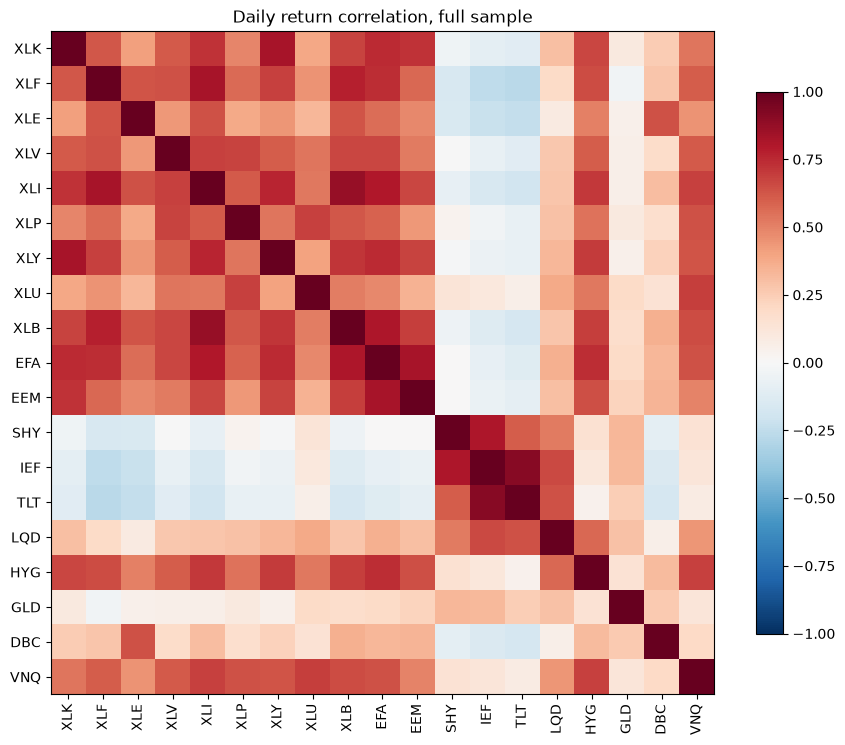

annualized volatility, low to high:
SHY    0.016
IEF    0.066
HYG    0.084
LQD    0.086
TLT    0.148
XLP    0.150
GLD    0.163
XLV    0.165
EFA    0.175
DBC    0.179
XLU    0.188
XLI    0.198
VNQ    0.198
XLB    0.207
EEM    0.208
XLY    0.217
XLF    0.225
XLK    0.246
XLE    0.293


In [ ]:
order = [a.ticker for a in UNIVERSE if a.role.value == "optimize"]
corr = returns[order].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_title("Daily return correlation, full sample")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

ann = (returns.std(ddof=1) * np.sqrt(252)).sort_values()
print("annualized volatility, low to high:")
print(ann.round(3).to_string())

Two things to notice here, because both come back later.

**These 19 assets are nowhere near 19 independent bets.** The universe is listed by asset class. Nearly everything on the equity side moves as one:
the nine sector funds plus EFA and EEM form a single deep-red 11x11 block, and VNQ and HYG behave like
members of it too - a high-yield credit fund is an equity bet wearing a bond label.
A second, smaller block covers the rate-sensitive funds (SHY, IEF, TLT, LQD). Between the equity
block and the Treasury funds the correlations turn faintly negative, and that pale blue rectangle
is essentially the whole diversification of this portfolio. GLD is the only asset that is
close to uncorrelated with everything else.

So the effective breadth is far below 19. It's something like an equity factor, a rates factor, and
gold. Two consequences. First, when several assets carry nearly the same information the
covariance matrix becomes numerically delicate: small changes in the inputs swing the answer
around, which is why ERC can only equalize risk contributions to within a small tolerance rather
than exactly (section 5 measures how small). Second, it explains a result that looks odd in the
exhibits: the risk-parity rules put a large share of their risk in bonds not because bonds are
attractive, but because they are the instruments with most of independent risk in this universe.

**Volatility spans nearly a factor of twenty**, from SHY at 1.6% annualized to XLE at 29.3%.
Inverse-vol and ERC both use that spread directly to size positions — more of the calm assets,
less of the loud ones. Equal weight ignores it, which is why an equally weighted book ends up
with its risk dominated by the most volatile symbols.


## 2. The signals, one layer at a time

The three signals are pure functions of the close panel, so they can be called and inspected
individually. The point of this section is the *architecture*: the composite is deliberately
**not** a uniform z-score of three equivalent inputs.


In [ ]:
scfg = CFG.signals
sig = sigma_daily(closes, scfg.signal_vol_halflife_days)

ts = tsmom(closes, scfg.tsmom_windows, scfg.signal_vol_halflife_days, sigma=sig)
xs = xsmom(closes, scfg.xs_lookback, scfg.xs_exclude)
rv = st_rev(closes, scfg.reversal_window, scfg.clip)

pd.DataFrame(
    {"tsmom": ts["XLK"], "xsmom": xs["XLK"], "st_rev": rv["XLK"]}
).dropna().tail()

,tsmom,xsmom,st_rev
date,,,
2026-07-06,1.674603,1.0,1.179871
2026-07-07,1.767021,1.0,-0.360865
2026-07-08,1.553213,1.0,1.783526
2026-07-09,1.634567,1.0,1.950660
2026-07-10,1.648526,1.0,0.409369


/tmp/ipykernel_64942/2099807320.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, ncol=3, fontsize=8)


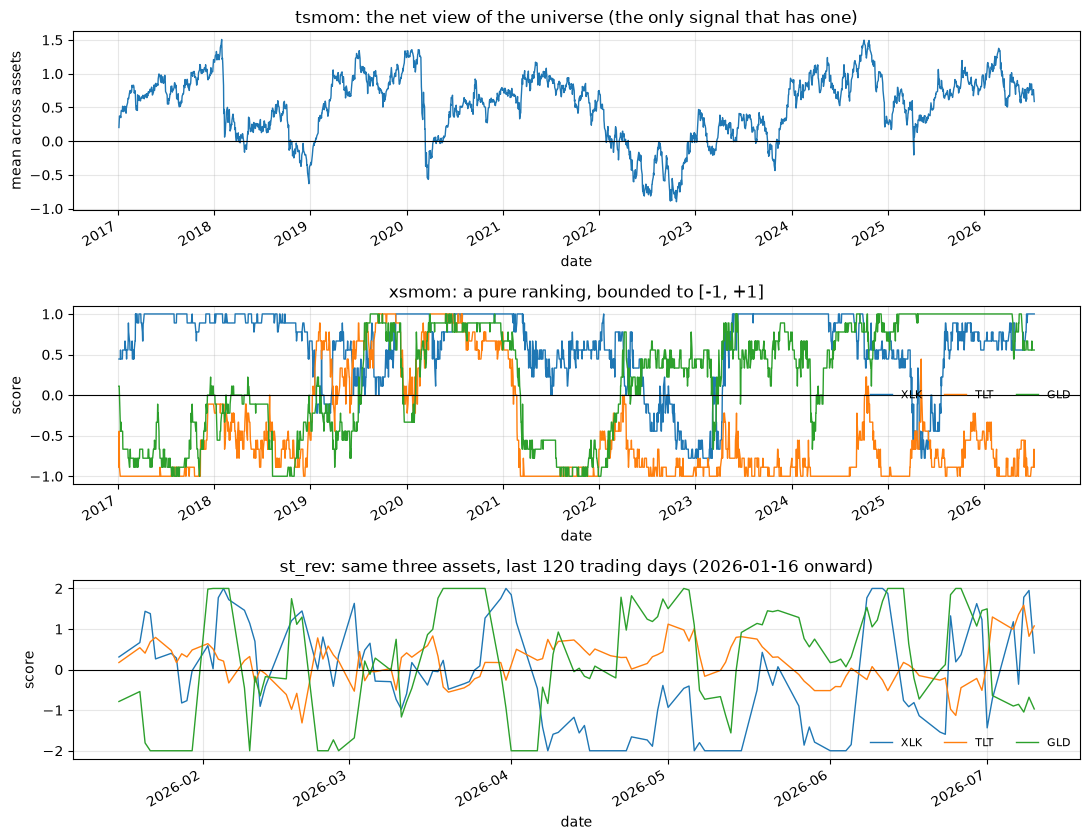

per-asset score ranges over the full sample:

xsmom:
       XLK    TLT    GLD
min -0.889 -1.000 -1.000
max  1.000  1.000  1.000
std  0.471  0.643  0.675

st_rev:
       XLK    TLT    GLD
min -2.000 -2.000 -2.000
max  2.000  2.000  2.000
std  1.107  1.067  1.095


In [ ]:
SHOW = ["XLK", "TLT", "GLD"]  # equity, long duration, the one uncorrelated asset

# xsmom's cross-sectional mean is an identity, not an observation: a centered rank
# averages to zero. Assert it rather than plotting a line of floating-point noise.
assert xs.mean(axis=1).abs().max() < 1e-12, "xsmom is no longer mean-zero"

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5))

ts.mean(axis=1).dropna().plot(
    ax=axes[0], color="tab:blue", linewidth=1.0, label="tsmom"
)
axes[0].set_ylabel("mean across assets")
axes[0].set_title("tsmom: the net view of the universe (the only signal that has one)")

xs[SHOW].dropna().plot(ax=axes[1], linewidth=1.0)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_ylabel("score")
axes[1].set_title("xsmom: a pure ranking, bounded to [-1, +1]")

tail = rv[SHOW].dropna().tail(120)
tail.plot(ax=axes[2], linewidth=1.0)
axes[2].set_ylabel("score")
axes[2].set_title(
    f"st_rev: same three assets, last 120 trading days ({tail.index[0].date()} onward)"
)

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, ncol=3, fontsize=8)
axes[2].set_xlabel("date")
plt.tight_layout()
plt.show()

print("per-asset score ranges over the full sample:")
for name, frame in (("xsmom", xs), ("st_rev", rv)):
    d = frame[SHOW].describe().loc[["min", "max", "std"]]
    print(f"\n{name}:\n{d.round(3).to_string()}")

Three different things are on display here, and only the first one is about the market.

**`tsmom` carries a net view.** Its cross-sectional mean wanders freely: strongly positive
through 2017, collapsing in early 2020 and again through 2022, recovering after. Those are the
risk-on and risk-off regimes.

**`xsmom` is a slow rotation.** The three lines drift between the bounds over months, and both
bounds are attained exactly. On any given day some asset is ranked best (+1) and some worst
(-1). Watch the lines cross: this signal has nothing to say about whether to be invested, only
about which assets to prefer over which others.

**`st_rev` runs on a much shorter clock**, which is why the bottom panel is zoomed to the last
120 days. Over the full sample it is an unreadable band. Note that the clip binds: TLT and GLD
reach exactly ±2 in the table below.

This is the entire reason the combine is *differential* rather than a uniform z-score of three
inputs. Z-scoring all three per day would demean `tsmom` and delete the only channel that
carries a net view of the market. The composite would still rank assets perfectly well, and
would have nothing left to say about how much exposure to take.

## 3. One rebalance, taken apart

`run_backtest` is a loop around a handful of calls. Here is a single iteration of that loop, done by hand on the last rebalance date, so the intermediate objects are visible.


In [ ]:
day = returns.index[-1]
pos = returns.index.get_loc(day)
window = returns.iloc[
    pos - CFG.estimation.cov_window_days : pos
]  # ends at t-1: the PIT rule

sigma = ewma_cov(window, CFG.estimation.ewma_halflife_days)
mu = expected_returns(closes, CFG.signals).loc[day]

print(
    f"rebalance {day.date()}:"
    f" window {window.index[0].date()} .. {window.index[-1].date()}"
    f" ({len(window)} rows)"
)
print(
    f"predicted portfolio vol of an equal-weight book: "
    f"{np.sqrt(np.ones(19) @ sigma.to_numpy() @ np.ones(19) / 19**2) * np.sqrt(252):.2%} annualized"  # noqa: E501
)
mu.sort_values(ascending=False).head()

rebalance 2026-07-10: window 2025-07-09 .. 2026-07-09 (252 rows)
predicted portfolio vol of an equal-weight book: 8.40% annualized


XLK    0.024999
EEM    0.017030
XLI    0.011737
XLB    0.007142
EFA    0.004243
Name: 2026-07-10 00:00:00, dtype: float64

In [ ]:
weights = {name: optimize(name, mu, sigma, None, CFG) for name in OPTIMIZER_NAMES}
book = pd.DataFrame(weights)
book.loc["-- gross --"] = book.abs().sum()
book.loc["-- net --"] = book.iloc[:-1].sum()
book.round(3)

,equal_weight,erc,inverse_vol,mvo,mvo_ls
XLK,0.053,0.021,0.016,0.250,0.250
XLF,0.053,0.038,0.031,0.000,-0.250
XLE,0.053,0.054,0.020,0.082,0.000
XLV,0.053,0.030,0.028,0.000,0.073
XLI,0.053,0.020,0.025,0.250,0.250
XLP,0.053,0.046,0.031,0.000,0.000
XLY,0.053,0.023,0.024,0.000,-0.000
XLU,0.053,0.030,0.029,0.000,0.000
XLB,0.053,0.017,0.024,0.000,0.068
EFA,0.053,0.018,0.026,0.000,-0.047


Five allocation rules, one interface, same inputs. Now decompose the risk of each and check the
contract that defines ERC.


In [ ]:
shares = pd.DataFrame({n: pct_risk_contributions(w, sigma) for n, w in weights.items()})

worst = float((shares["erc"] - 1 / len(shares)).abs().max())
print(f"ERC: worst deviation from 1/n = {worst:.2e}  (1/n = {1 / len(shares):.4f})")
print("every column sums to 1.0:", shares.sum().round(10).to_dict())

cls = {a.ticker: a.asset_class.value for a in UNIVERSE}
by_class = shares.groupby(shares.index.map(cls)).sum()
by_class.round(3)

ERC: worst deviation from 1/n = 2.81e-07  (1/n = 0.0526)
every column sums to 1.0: {'equal_weight': 1.0, 'erc': 1.0, 'inverse_vol': 1.0, 'mvo': 1.0, 'mvo_ls': 1.0}


,equal_weight,erc,inverse_vol,mvo,mvo_ls
commodity,0.111,0.105,0.032,0.000,-0.070
credit,0.042,0.105,0.158,0.000,-0.000
duration,0.048,0.158,0.199,0.000,-0.029
intl_equity,0.232,0.105,0.145,0.284,0.390
reit,0.049,0.053,0.060,0.038,0.024
us_sector,0.517,0.474,0.406,0.678,0.684


The Euler decomposition is exact, so each column is a genuine risk budget that sums to one.
Reading across: MVO concentrates almost everything in equities because that is where its
estimated expected returns point, while the three signal-free rules spread risk across all six
classes. Negative entries under `mvo_ls` are short positions acting as hedges — assets whose
marginal effect is to *reduce* portfolio volatility.


## 4. Three questions the exhibits did not answer

Everything so far was inspection, while this section is research. We ask three questions, each answered by
building a config variant with `dataclasses.replace` and re-running.

All three use **weekly** rebalancing to keep the notebook to a few minutes.


In [20]:
BASE = replace(CFG, engine=replace(CFG.engine, rebalance_freq='W-FRI'))
SPY = close_panel(load_universe_bars(tickers=('SPY',)))['SPY']

### 4a. When does shrinkage actually help?

Ledoit-Wolf's argument is about T/N — observations per asset:

- Few observations per asset → noisy sample covariance → a simple target helps.
- Many observations → the sample covariance is already fine → shrinkage buys nothing.

Here N = 19 and the default window is T = 252, so T/N ≈ 13. That is well inside the "already
fine" region. So the prediction is: shrinkage should be close to worthless at the default, and
start to matter as the window shrinks.

Testing that needs a metric that isolates Σ. Sharpe will not do — it is driven by μ, by costs,
and by a single realized path, so a second-order improvement in Σ would be invisible.

The capped minimum-variance portfolio is the right instrument:

- Its objective contains only Σ. No expected returns anywhere.
- A better risk model therefore shows up directly, as lower realized volatility.

`mvo` becomes that portfolio once the expected-return term stops mattering. No mock needed: μ
trades one-for-one against γ, so setting `risk_aversion` very high is the same as sending μ to
zero.

In [ ]:
WINDOWS = (63, 126, 252, 504)  # T/N = 3.3, 6.6, 13.3, 26.5 at N = 19

MINVAR = replace(
    BASE,
    construction=replace(BASE.construction, risk_aversion=1e6, turnover_lambda=0.0),
)

runs = {}
for w in WINDOWS:
    for est in ("ewma", "lw_cc"):
        cfg = replace(
            MINVAR,
            estimation=replace(MINVAR.estimation, cov_window_days=w, cov_estimator=est),
        )
        print(f"window={w:3d} {est} ...", flush=True)
        try:
            runs[(w, est)] = run_backtest(closes, "mvo", cfg)
        except (RuntimeError, ValueError) as exc:
            print(f"   -> refused: {exc}")

# sanity check: with gamma this large the book really is minimum-variance
probe = returns.iloc[-CFG.estimation.cov_window_days :]
s = ewma_cov(probe, CFG.estimation.ewma_halflife_days)
w_gamma = optimize("mvo", mu, s, None, MINVAR)
w_zero = optimize(
    "mvo",
    pd.Series(0.0, index=s.index),
    s,
    None,
    replace(BASE, construction=replace(BASE.construction, turnover_lambda=0.0)),
)
print(
    "\nlargest weight difference vs a true mu=0 solve: "
    f"{(w_gamma - w_zero).abs().max():.2e}"
)

window= 63 ewma ...
window= 63 lw_cc ...
window=126 ewma ...
window=126 lw_cc ...
window=252 ewma ...
window=252 lw_cc ...
window=504 ewma ...
window=504 lw_cc ...

largest weight difference vs a true mu=0 solve: 7.51e-05


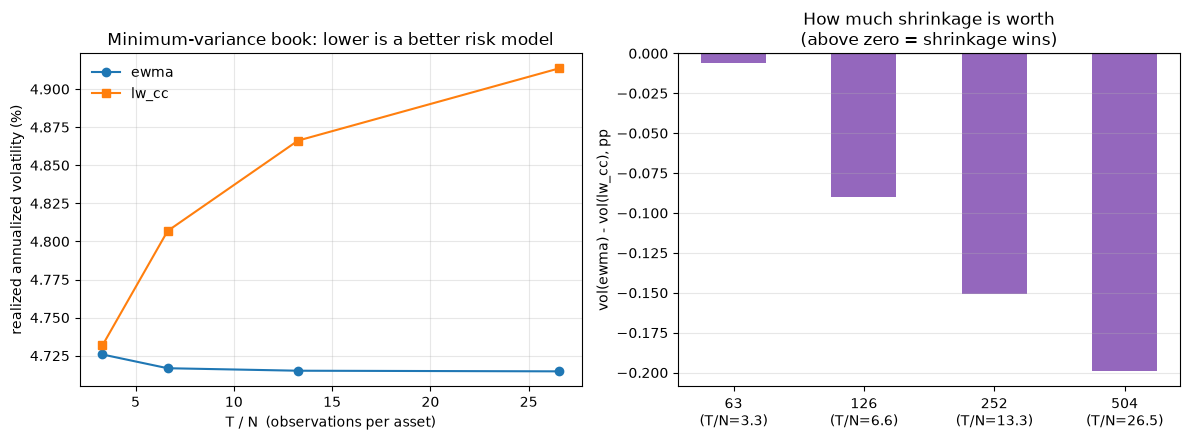

compared on 2018-01-05 onward, 2138 days


,ewma,lw_cc
cov_window_days,,
63,4.726,4.732
126,4.717,4.807
252,4.715,4.866
504,4.715,4.914


In [ ]:
# a longer window starts later, so compare every run on the dates they all share
start = max(r.net_returns.index[0] for r in runs.values())
rows = {}
for (w, est), r in runs.items():
    rows.setdefault(w, {})[est] = float(
        r.net_returns.loc[start:].std(ddof=1) * np.sqrt(252)
    )

vol = pd.DataFrame(rows).T.sort_index() * 100
vol.index.name = "cov_window_days"
tn = vol.index / closes.shape[1]

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))

for est, marker in (("ewma", "o"), ("lw_cc", "s")):
    left.plot(tn, vol[est], marker=marker, label=est)
left.set_xlabel("T / N  (observations per asset)")
left.set_ylabel("realized annualized volatility (%)")
left.set_title("Minimum-variance book: lower is a better risk model")
left.legend(frameon=False)
left.grid(alpha=0.3)

right.bar(range(len(vol)), vol["ewma"] - vol["lw_cc"], 0.5, color="tab:purple")
right.set_xticks(range(len(vol)))
right.set_xticklabels(
    [f"{w}\n(T/N={r:.1f})" for w, r in zip(vol.index, tn, strict=True)]
)
right.axhline(0, color="black", linewidth=0.8)
right.set_ylabel("vol(ewma) - vol(lw_cc), pp")
right.set_title("How much shrinkage is worth\n(above zero = shrinkage wins)")
right.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

sample = next(iter(runs.values()))  # any surviving run shares the comparison window
print(f"compared on {start.date()} onward, {len(sample.net_returns.loc[start:])} days")
vol.round(3)

The prediction was wrong, and the way it failed is more informative than a confirmation would
have been.

**EWMA is flat.** 4.726% at a 63-day window, 4.715% at 504. Lengthening the window changes
nothing, because a halflife of 63 days already caps the effective sample at roughly 126 days.
Rows beyond that arrive with near-zero weight. The nominal window is not the binding parameter
here; the halflife is.

**Shrinkage gets worse with more data.** 4.732% at 63 days, rising to 4.914% at 504. That looks
backwards until you remember Ledoit-Wolf runs on an *equally weighted* sample. A 504-day
equal-weighted covariance averages in market conditions from two years ago, so a longer window
buys staleness, not precision.

**Shrinkage never wins.** It ties at 63 days and loses by 0.2pp at 504.

So the binding constraint at daily frequency is not estimation noise, it is non-stationarity.
Volatility clusters, and weighting recent days more heavily is worth more than shrinking toward a
stable target. T/N never gets to be the problem - partly because, as section 1 showed, 19 assets
that behave like three factors have far fewer effective dimensions than N = 19 suggests, so the
sample covariance was never as data-starved as the nominal ratio implies.

Two practical consequences. The README limitation about EWMA and shrinkage not composing costs
nothing here: the estimator that cannot be combined with shrinkage is the one that wins anyway.
And the parameter worth sweeping is `ewma_halflife_days`, not `cov_window_days`.

Note what this does **not** measure: whether a better covariance matrix makes money. It measures
whether a better covariance matrix is a better *forecast*. Those are different questions.


### 4b. Is the no-trade band a substitute for the turnover penalty?

The engine has two levers on turnover: $\lambda$ inside the objective, and a no-trade band at
execution. The exhibits sweep $\lambda$ and never touch the band, which is left at zero. They
act very differently — $\lambda$ makes each trade justify its own cost before the optimizer
takes it, while the band is a blunt filter applied after the optimizer has already decided.


In [ ]:
bands = (0.0, 0.002, 0.005, 0.01, 0.02)
rows = {}
for b in bands:
    cfg = replace(BASE, engine=replace(BASE.engine, no_trade_band=b))
    print(f"band={b} ...", flush=True)
    rows[b] = performance_stats(run_backtest(closes, "mvo", cfg))

band_table = pd.DataFrame(rows).T[
    ["sharpe", "cagr", "ann_turnover", "cost_drag", "max_drawdown"]
]
band_table.index.name = "no_trade_band"
band_table.round(4)

band=0.0 ...
band=0.002 ...
band=0.005 ...
band=0.01 ...
band=0.02 ...


,sharpe,cagr,ann_turnover,cost_drag,max_drawdown
no_trade_band,,,,,
0.000,0.7008,0.0882,40.1656,0.0201,-0.2084
0.002,0.7010,0.0882,40.1281,0.0201,-0.2083
0.005,0.7033,0.0884,40.0405,0.0200,-0.2080
0.010,0.7037,0.0883,39.8824,0.0199,-0.2080
0.020,0.7060,0.0886,39.6865,0.0198,-0.2076


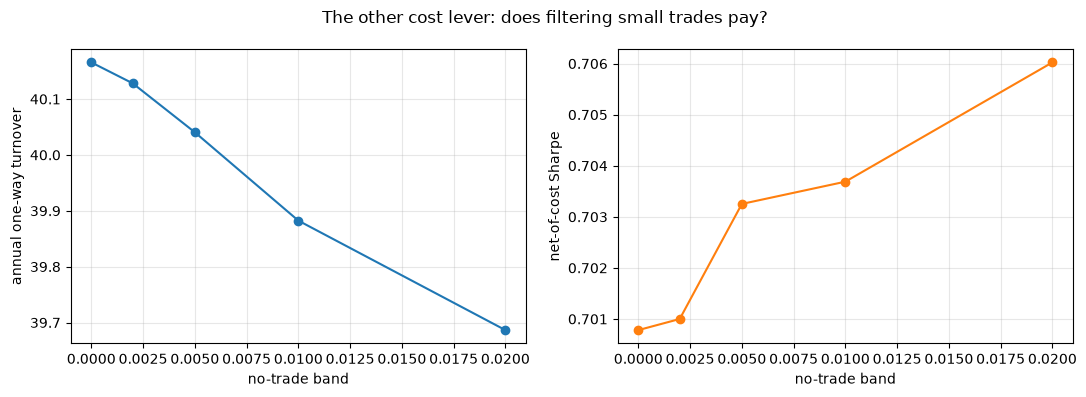

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(band_table.index, band_table["ann_turnover"], marker="o")
axes[0].set_xlabel("no-trade band")
axes[0].set_ylabel("annual one-way turnover")
axes[1].plot(band_table.index, band_table["sharpe"], marker="o", color="tab:orange")
axes[1].set_xlabel("no-trade band")
axes[1].set_ylabel("net-of-cost Sharpe")
for a in axes:
    a.grid(alpha=0.3)
fig.suptitle("The other cost lever: does filtering small trades pay?")
plt.tight_layout()
plt.show()

The band barely does anything. A 2% threshold - wide, for a 19-asset book - cuts annual turnover
from 40.2 to 39.7, about 1%. Sharpe rises monotonically across the sweep, but by 0.005 in total.

The reason is the size of the trades. At 40x annual turnover on a weekly schedule the average
rebalance moves roughly 0.77 of the book across 19 assets, call it 4% per asset. Almost every trade
is already larger than the band, so the band only catches a thin tail of small adjustments. To
bite at all it would have to be several times wider, and by then it would be blocking the large
trades that carry the signal.

That is the difference between the two levers, and it is not about strength:

- The lambda penalty sits **inside** the objective. The optimizer sees what each trade costs before
  deciding, gives up the ones that do not cover it, and keeps the rest.
- The band sits **outside**, applied after the optimizer has already chosen. It discriminates by
  trade size, never by whether the trade was worth making.

The comparison is direct. Weekly `mvo` starts at Sharpe 0.701 in both experiments - the README's
lambda sweep lifts it to 0.766, the band here lifts it to 0.706. Same objective, same starting
point, same intent. One lever is worth 0.065, the other 0.005. Where a cost control is applied
matters more than how hard it is pushed.


### 4c. Which signal is actually carrying the strategy?

Three signals go into `mu`, and nothing in the exhibits separates them. Drop one at a time and
re-run: whatever the removal costs is what that signal was contributing.

Two things to say before the numbers, because both affect how to read them.

**The library has no clean way to do this.** `run_backtest` builds `mu` internally from
`cfg.signals`, and no config setting can switch a component off — `xsmom_scale` has to be
positive, and `clip` is shared with `st_rev`. So the code below replaces `expected_returns` with
a patched version for the duration of each run. It works, but needing a mock to ask an obvious
research question is a gap in the design, not a clever trick. An optional `mu_panel` argument on
`run_backtest` would make this a first-class experiment, and it is now on the list.

**Dropping a signal must not quietly shrink the position size.** The composite normally averages
three components. If we removed one and still divided by three, `mu` would come out smaller, and
because `mu` trades one-for-one against the risk-aversion `gamma`, the optimizer would simply
take smaller positions. We would then be measuring "smaller book" instead of "less information".
Dividing by the number of surviving components keeps the scale intact so the comparison is about
content.

In [ ]:
def ablated_expected_returns(drop):
    """expected_returns with one component removed, rescaled to keep mu comparable."""

    def build(cl, scfg):
        sig = sigma_daily(cl, scfg.signal_vol_halflife_days)
        parts = {
            "tsmom": tsmom(
                cl, scfg.tsmom_windows, scfg.signal_vol_halflife_days, sigma=sig
            ).clip(-scfg.clip, scfg.clip),
            "xsmom": scfg.xsmom_scale * xsmom(cl, scfg.xs_lookback, scfg.xs_exclude),
            "st_rev": st_rev(cl, scfg.reversal_window, scfg.clip),
        }
        kept = [v for name, v in parts.items() if name != drop]
        total = kept[0]
        for extra in kept[1:]:
            total = total + extra
        return (total / len(kept)) * sig

    return build


# a cost-aware config with lambda=0. The result is dominated by turnover, not by signal.
ABL = replace(BASE, construction=replace(BASE.construction, turnover_lambda=3e-3))

scores = {"all three": performance_stats(run_backtest(closes, "mvo", ABL))}
for drop in ("tsmom", "xsmom", "st_rev"):
    print(f"dropping {drop} ...", flush=True)
    with patch("portlab.engine.expected_returns", ablated_expected_returns(drop)):
        scores[f"without {drop}"] = performance_stats(run_backtest(closes, "mvo", ABL))

abl = pd.DataFrame(scores).T[
    ["sharpe", "cagr", "ann_vol", "max_drawdown", "ann_turnover"]
]
abl["sharpe_delta"] = abl["sharpe"] - abl.loc["all three", "sharpe"]
abl.round(4)

dropping tsmom ...
dropping xsmom ...
dropping st_rev ...


,sharpe,cagr,ann_vol,max_drawdown,ann_turnover,sharpe_delta
all three,0.7662,0.0993,0.1356,-0.2008,11.3705,0.0000
without tsmom,0.7591,0.1042,0.1444,-0.2245,25.6957,-0.0071
without xsmom,0.6576,0.0737,0.1189,-0.2093,31.7412,-0.1087
without st_rev,0.8422,0.1170,0.1437,-0.2019,4.3518,0.0759


Read `sharpe_delta` and `ann_turnover` together - the turnover column turns out to be the more
revealing of the two.

**`st_rev` is pure cost.** Removing it *improves* Sharpe by 0.076 and cuts turnover by 62%, from
11.4 to 4.4 per year. It was generating most of the trading and getting nothing back for it. That
is exactly the failure the design notes anticipated: short-term reversal is a single-name
microstructure effect, visible when individual stocks overshoot and snap back, and there is no
reason for it to survive aggregating thousands of names into a sector ETF. The guess is now tested
rather than asserted, and it was right.

**`xsmom` is the workhorse.** Dropping it costs 0.109 of Sharpe, by far the largest loss, and it is
the only component whose removal makes the book clearly worse on every metric that matters.

**`tsmom` earns its place through turnover, not return.** Its Sharpe delta is -0.007, effectively
nothing. But removing it more than doubles turnover, from 11.4 to 25.7. The slow-moving absolute
signal is acting as ballast, holding positions still while the faster components churn.

One limit on what this can tell you. Only `mvo` and `mvo_ls` read `mu` at all; the other three
rules ignore it completely. So this experiment measures each signal **as seen through one
optimizer that is itself damaged by estimation error**. A signal could be genuinely useful and
still show a small delta here, simply because MVO cannot exploit it. Separating "weak signal"
from "optimizer that cannot use it" would need a different test — an information coefficient
against forward returns, which never touches the optimizer at all.

## 5. Failure modes and numerical limits

Two questions decide whether a library can be trusted with a real decision:

- What does it do when the inputs are wrong?
- Does it know the limits of its own accuracy?

In [ ]:
broken = closes.copy()
broken.iloc[len(broken) // 2, 3] = np.nan  # one hole, mid-sample
try:
    run_backtest(broken, "erc", CFG)
except ValueError as exc:
    print("NaN panel      ->", exc)

try:
    run_backtest(closes, "magic", CFG)
except ValueError as exc:
    print("unknown rule   ->", str(exc)[:70], "...")

try:
    run_backtest(closes.iloc[:30], "erc", CFG)
except ValueError as exc:
    print("sample too short ->", exc)

NaN panel      -> NaN in closes. The engine requires a complete panel.
unknown rule   -> Unknown optimizer 'magic'. Available: ('equal_weight', 'erc', 'inverse ...
sample too short -> No rebalance date has both a full covariance window and a complete mu row. Extend the sample or shrink the warm-up.


Three mistakes, three refusals, no output. By design:

- A missing price is not filled forward.
- An unrecognised optimizer name does not fall back to a default.
- A sample too short to warm up the signals does not return a partial backtest.

The alternatives are worse in the same way — they all return a number:

- Forward-filling gives a return of exactly zero. That reads as a calm day, not as missing data.
- A silent fallback gives you somebody else's strategy.
- A partial backtest gives you a Sharpe ratio computed on the warm-up period.

Each is plausible enough to end up in a report. Raising is the only outcome that cannot.

The second limit is numerical.

- ERC has no closed form, so it is solved iteratively.
- After solving, it checks its own answer against the definition.
- If the risk contributions are not equal to within tolerance, it raises instead of returning.

The tolerance is measured, not chosen: scanning every rebalance in the sample, the worst
equal-risk error was about 5e-5, so the threshold sits at 1e-4. Below is the hardest day.

In [ ]:
from portlab.construction import ERC_CONTRIBUTION_TOL

# the worst-conditioned Sigma in the sample; snap to the nearest trading day so this
# stays valid if the cache is refreshed
pos = int(returns.index.get_indexer([pd.Timestamp("2020-10-30")], method="nearest")[0])
worst_day = returns.index[pos]
sigma_bad = ewma_cov(
    returns.iloc[pos - CFG.estimation.cov_window_days : pos],
    CFG.estimation.ewma_halflife_days,
)

w_erc = optimize(
    "erc", expected_returns(closes, CFG.signals).loc[worst_day], sigma_bad, None, CFG
)
dev = float((pct_risk_contributions(w_erc, sigma_bad) - 1 / 19).abs().max())

print(f"condition number of Sigma : {np.linalg.cond(sigma_bad.to_numpy()):.3e}")
print(f"worst deviation from 1/n  : {dev:.3e}")
print(f"accepted tolerance        : {ERC_CONTRIBUTION_TOL:.0e}")
print(f"headroom                  : {ERC_CONTRIBUTION_TOL / dev:.1f}x")

condition number of Sigma : 2.697e+04
worst deviation from 1/n  : 5.305e-05
accepted tolerance        : 1e-04
headroom                  : 1.9x


The condition number here is 2.7e4, and it is the diagnostic to read. Roughly, it says how much
the solver can amplify small errors in its input: at this level you can expect to lose about four
of the sixteen digits a float carries. Hence contributions landing near 1e-5 rather than at
machine precision.

The cause is back in section 1:

- The rate-sensitive funds carry nearly the same information.
- So the covariance matrix is close to singular — several assets, one underlying bet.
- Hierarchical risk parity attacks exactly this: cluster first, allocate across clusters, and each
  optimization sees a small well-behaved matrix. First item on the roadmap.

What this section does **not** show: that the strategy is any good. Only that when the library
cannot answer, it says so — and when it can, it knows how many digits to believe.